# 2.1 Modeling

This step aims to define which model would be best for our business problem. A total of 7 different models will be evaluated to obtain a good standard.

## Importing Libs

In [1]:
# Importing Libs
    
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
import time

from sklearn.dummy import DummyClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report,accuracy_score, recall_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier


from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import warnings



sns.set_theme(style="darkgrid", rc={'figure.figsize':(10,6)})

## Importing Dataset and Feature Engeneering

In this step:
- The dataset was imported
- The values created in section **1 - EDA.ipynb**, `balanceOrigDiff` and `balanceDestDiff` were used
- Values that would not be relevant in the forecast were removed

In [2]:
FRAUD_PATH = "datasets/AIML Dataset.csv"

df = pd.read_csv(FRAUD_PATH)

categorical_features = ['type', 'nameOrig', 'nameDest', 'isFraud', 'isFlaggedFraud']
numerical_features = ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']

df['balanceOrigDiff'] = df['newbalanceOrig'] - df['oldbalanceOrg']
df['balanceDestDiff'] = df['newbalanceDest'] - df['oldbalanceDest']

features_model = numerical_features + ['balanceOrigDiff', 'balanceDestDiff', 'isFraud']
df_model = df[features_model]

df_model.head()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,balanceOrigDiff,balanceDestDiff,isFraud
0,1,9839.64,170136.0,160296.36,0.0,0.0,-9839.64,0.0,0
1,1,1864.28,21249.0,19384.72,0.0,0.0,-1864.28,0.0,0
2,1,181.00,181.0,0.00,0.0,0.0,-181.00,0.0,1
3,1,181.00,181.0,0.00,21182.0,0.0,-181.00,-21182.0,1
4,1,11668.14,41554.0,29885.86,0.0,0.0,-11668.14,0.0,0


## Train Test Split

The data was divided as follows:
- The class of interest (`isFraud`) was separated as **y** and the others as **X**
- The division was made in a 70-30 ratio due to the high volume of data
- The `stratify` hyperparameter was used in order to maintain the proportion of positive and negative classes for both the test set and the training set
- Since there are no categorical values, it was only necessary to make the `StandardScaler`

In [3]:
y = df_model["isFraud"]
X = df_model.drop("isFraud", axis = 1)

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, stratify=y, random_state = 42)

In [5]:
scaler =  StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

`StratifiedKFold` is used to divide the data into K parts (folds) to perform cross-validation, maintaining the proportion of classes in each fold.
In other words, in each Cross-Validation it is guaranteed that each fold has representation of the classes.

In [6]:
stratified_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

## Testing Models

7 different models will then be tested to evaluate their performance:
- Dummy Classifier
- Logistic Regression
- Decision Tree
- Naive Bayes
- KNN
- XGB
- LGBM

From these models, the following metrics will be evaluated:

- `accuracy`: Proportion of correct predictions (both positive and negative).
- `balanced_accuracy`: Average sensitivity (recall) of each class.
- `f1`: Harmonic mean between precision and recall. Preferable when you want a balance between false positives and false negatives.
- `precision`: Among the positive predictions, how many are actually positive. Ideal for high false positive costs.
- `recall`: Among the real positives, how many were correctly identified. Ideal for high false negative costs.
- `roc_auc` (or AUROC): Area under the ROC curve, which measures the model's ability to distinguish between classes. The closer to 1, the better.
- `average_precision` (or AUPRC): Area under the Precision-Recall curve. Effective for imbalanced data with a focus on the positive class.
- `neg_brier_score`: Mean squared error between the predicted probability and the actual label (more negative value = better).
- `f1_weighted`: Weighted average of the F1 of each class, considering the number of instances per class.

From this data, two things should be considered:
- The _execution time_ to train the model
- The _applicability_ of the metric to the business problem involved.

Given that the business problem is fraudulent transactions, it is much more interesting to **sacrifice Precision values** to have **gains in Recall**, in order to capture the highest possible fraud value, even though this would mean avoiding possible non-fraudulent transactions.
In addition, `average_precision` is also a great metric because it prioritizes positive classes.

In [8]:
models = {
    'Dummy Classifier': DummyClassifier(),
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(),
    'Naive Bayes': GaussianNB(),
    'KNN': KNeighborsClassifier(),
    'XGB': XGBClassifier(),
    'LGBM': LGBMClassifier()
}

MODEL_EVALUATION_METRICS = [
    "accuracy",
    "balanced_accuracy",
    "f1",
    "precision",
    "recall",
    "roc_auc",
    "average_precision",
    "neg_brier_score",
    "f1_weighted",
]

In [10]:
def train_model(TRAIN_X: pd.DataFrame, TRAIN_Y, MODEL, CV, SCORING):
    """
    Convert the results from training models to DataFrame with model name, splits and scores.

    Parameters
    ----------
   TRAIN_X: pd.DataFrame
        Training set.

    TRAIN_X: pd.Series
        Training target.

    MODEL: dict
        Dictionary with estimators and names.

    CV: 
        Cross-Validation estimator.

    SCORING: dict
        Dictionary with scoring evaluation metrics.

    Returns
    -------
    dict
        Dictionary with results from estimators.
    """

    results = {}

    with warnings.catch_warnings():
        warnings.filterwarnings("ignore")

        for model_name, classifier in MODEL.items():
            results[model_name] = cross_validate(estimator = classifier, 
                                                 X = TRAIN_X, 
                                                 y = TRAIN_Y, 
                                                 cv = CV,
                                                 scoring = SCORING)

    return results

In [11]:
results = train_model(MODEL = models, TRAIN_X = X_train, TRAIN_Y = y_train, CV = stratified_kfold, SCORING = MODEL_EVALUATION_METRICS)

[LightGBM] [Info] Number of positive: 4599, number of negative: 3558468
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.016353 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2040
[LightGBM] [Info] Number of data points in the train set: 3563067, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.001291 -> initscore=-6.651247
[LightGBM] [Info] Start training from score -6.651247
[LightGBM] [Info] Number of positive: 4599, number of negative: 3558468
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.054460 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2040
[LightGBM] [Info] Number of data points in the train set: 3563067, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.001291 -> initscore=-6.65124

In [168]:
def results_to_df(model_results, sum_time):
    """
    Convert the results from training models to DataFrame with model name, splits and scores.

    Parameters
    ----------
    model_results: dict
        Dictionary with results of models.

    sum_time: bool
        Boolean value to convert time values to it sum.

    Returns
    -------
    pd.DataFrame
        DataFrame with scores from models.
    """
    
    df = pd.DataFrame(model_results).T

    # list of columns
    col_list = df.columns.tolist()
    
    df = df.explode(col_list)
    df = df.reset_index()

    df[col_list] = df[col_list].astype(float)
    df.rename(columns={'index': 'models'}, inplace=True)

    if sum_time:
        df['total_time'] = df['fit_time'] + df['score_time']
        df = df.drop(columns=['fit_time', 'score_time'])
        
    return(df)

Below we observe the values for each of the 5 k folds for each test model:

In [26]:
df_results = results_to_df(results, sum_time = True)
df_results

,models,test_accuracy,test_balanced_accuracy,test_f1,test_precision,test_recall,test_roc_auc,test_average_precision,test_neg_brier_score,test_f1_weighted,total_time
0,Dummy Classifier,0.998709,0.500000,0.000000,0.000000,0.000000,0.500000,0.001291,-0.001289,0.998064,1.055676
1,Dummy Classifier,0.998709,0.500000,0.000000,0.000000,0.000000,0.500000,0.001291,-0.001289,0.998064,1.019034
2,Dummy Classifier,0.998709,0.500000,0.000000,0.000000,0.000000,0.500000,0.001291,-0.001289,0.998064,1.016106
3,Dummy Classifier,0.998709,0.500000,0.000000,0.000000,0.000000,0.500000,0.001291,-0.001289,0.998064,1.028000
4,Dummy Classifier,0.998710,0.500000,0.000000,0.000000,0.000000,0.500000,0.001290,-0.001288,0.998066,0.999037
5,Logistic Regression,0.999248,0.739525,0.621896,0.885852,0.479130,0.962167,0.609952,-0.000694,0.999136,3.923788
6,Logistic Regression,0.999233,0.734307,0.612152,0.882160,0.468696,0.958897,0.612170,-0.000695,0.999116,4.067495
7,Logistic Regression,0.999273,0.746919,0.636771,0.895899,0.493913,0.954672,0.619977,-0.000670,0.999167,3.652778
8,Logistic Regression,0.999255,0.738660,0.623156,0.897059,0.477391,0.955283,0.616341,-0.000681,0.999141,4.068419
9,Logistic Regression,0.999223,0.737113,0.611672,0.860979,0.474326,0.959104,0.604394,-0.000710,0.999111,3.686047


A better way to visualize this is to look at the average across folds:

In [28]:
df_results.groupby("models").mean().sort_values("test_average_precision")

,test_accuracy,test_balanced_accuracy,test_f1,test_precision,test_recall,test_roc_auc,test_average_precision,test_neg_brier_score,test_f1_weighted,total_time
models,,,,,,,,,,
Dummy Classifier,0.998709,0.500000,0.000000,0.000000,0.000000,0.500000,0.001291,-0.001289,0.998064,1.023571
Naive Bayes,0.990131,0.737086,0.113866,0.064692,0.483387,0.908744,0.080000,-0.009109,0.993900,2.086402
LGBM,0.995508,0.789643,0.450913,0.406245,0.583245,0.826532,0.325258,-0.004481,0.997032,8.508149
Logistic Regression,0.999246,0.739305,0.621129,0.884390,0.478691,0.958025,0.612567,-0.000690,0.999134,3.879705
KNN,0.999411,0.810178,0.730990,0.889611,0.620455,0.876654,0.672981,-0.000550,0.999358,196.844215
Decision Tree,0.999583,0.913018,0.836422,0.846968,0.826230,0.913018,0.700068,-0.000417,0.999580,72.954191
XGB,0.999675,0.898818,0.863685,0.941667,0.797700,0.999120,0.932269,-0.000258,0.999662,10.197282


With this we can see that the **XGB** model has the best AUPRC value (`test_average_precision`) and the second best `recall` value, so this will be the model used next. With this in mind, we will also analyze the distribution of the values:

In [164]:
def box_plots(df, x_val, y_val_list):
    """
    Convert the results from training models to DataFrame with model name, splits and scores.

    Parameters
    ----------
    df: pd.DataFrame
        DataFrame with scorings.

    x_val: str
        Value for the x axis.

    y_val_list: list
        List of parameters and scores to be analyzed.

    Returns
    -------
    Graphs
        Boxplots.
    """
    
    fig, axes = plt.subplots(5, 2, figsize=(14, 20), sharex=True)
    axes = axes.flatten()  # Transforma em vetor para facilitar iteração

    for i, y_val in enumerate(y_val_list):
        sns.boxplot(data=df, x=x_val, y=y_val, color='skyblue', showfliers=True, ax=axes[i])
        axes[i].set_title(f'{y_val} Boxplot', fontsize=12)
        axes[i].set_xlabel(x_val)
        axes[i].set_ylabel(y_val)
        axes[i].tick_params(axis="x", rotation=45, labelsize="small")

    # Remove subplots vazios (caso y_val_list tenha menos de 10 elementos)
    for j in range(len(y_val_list), len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

    return(None)

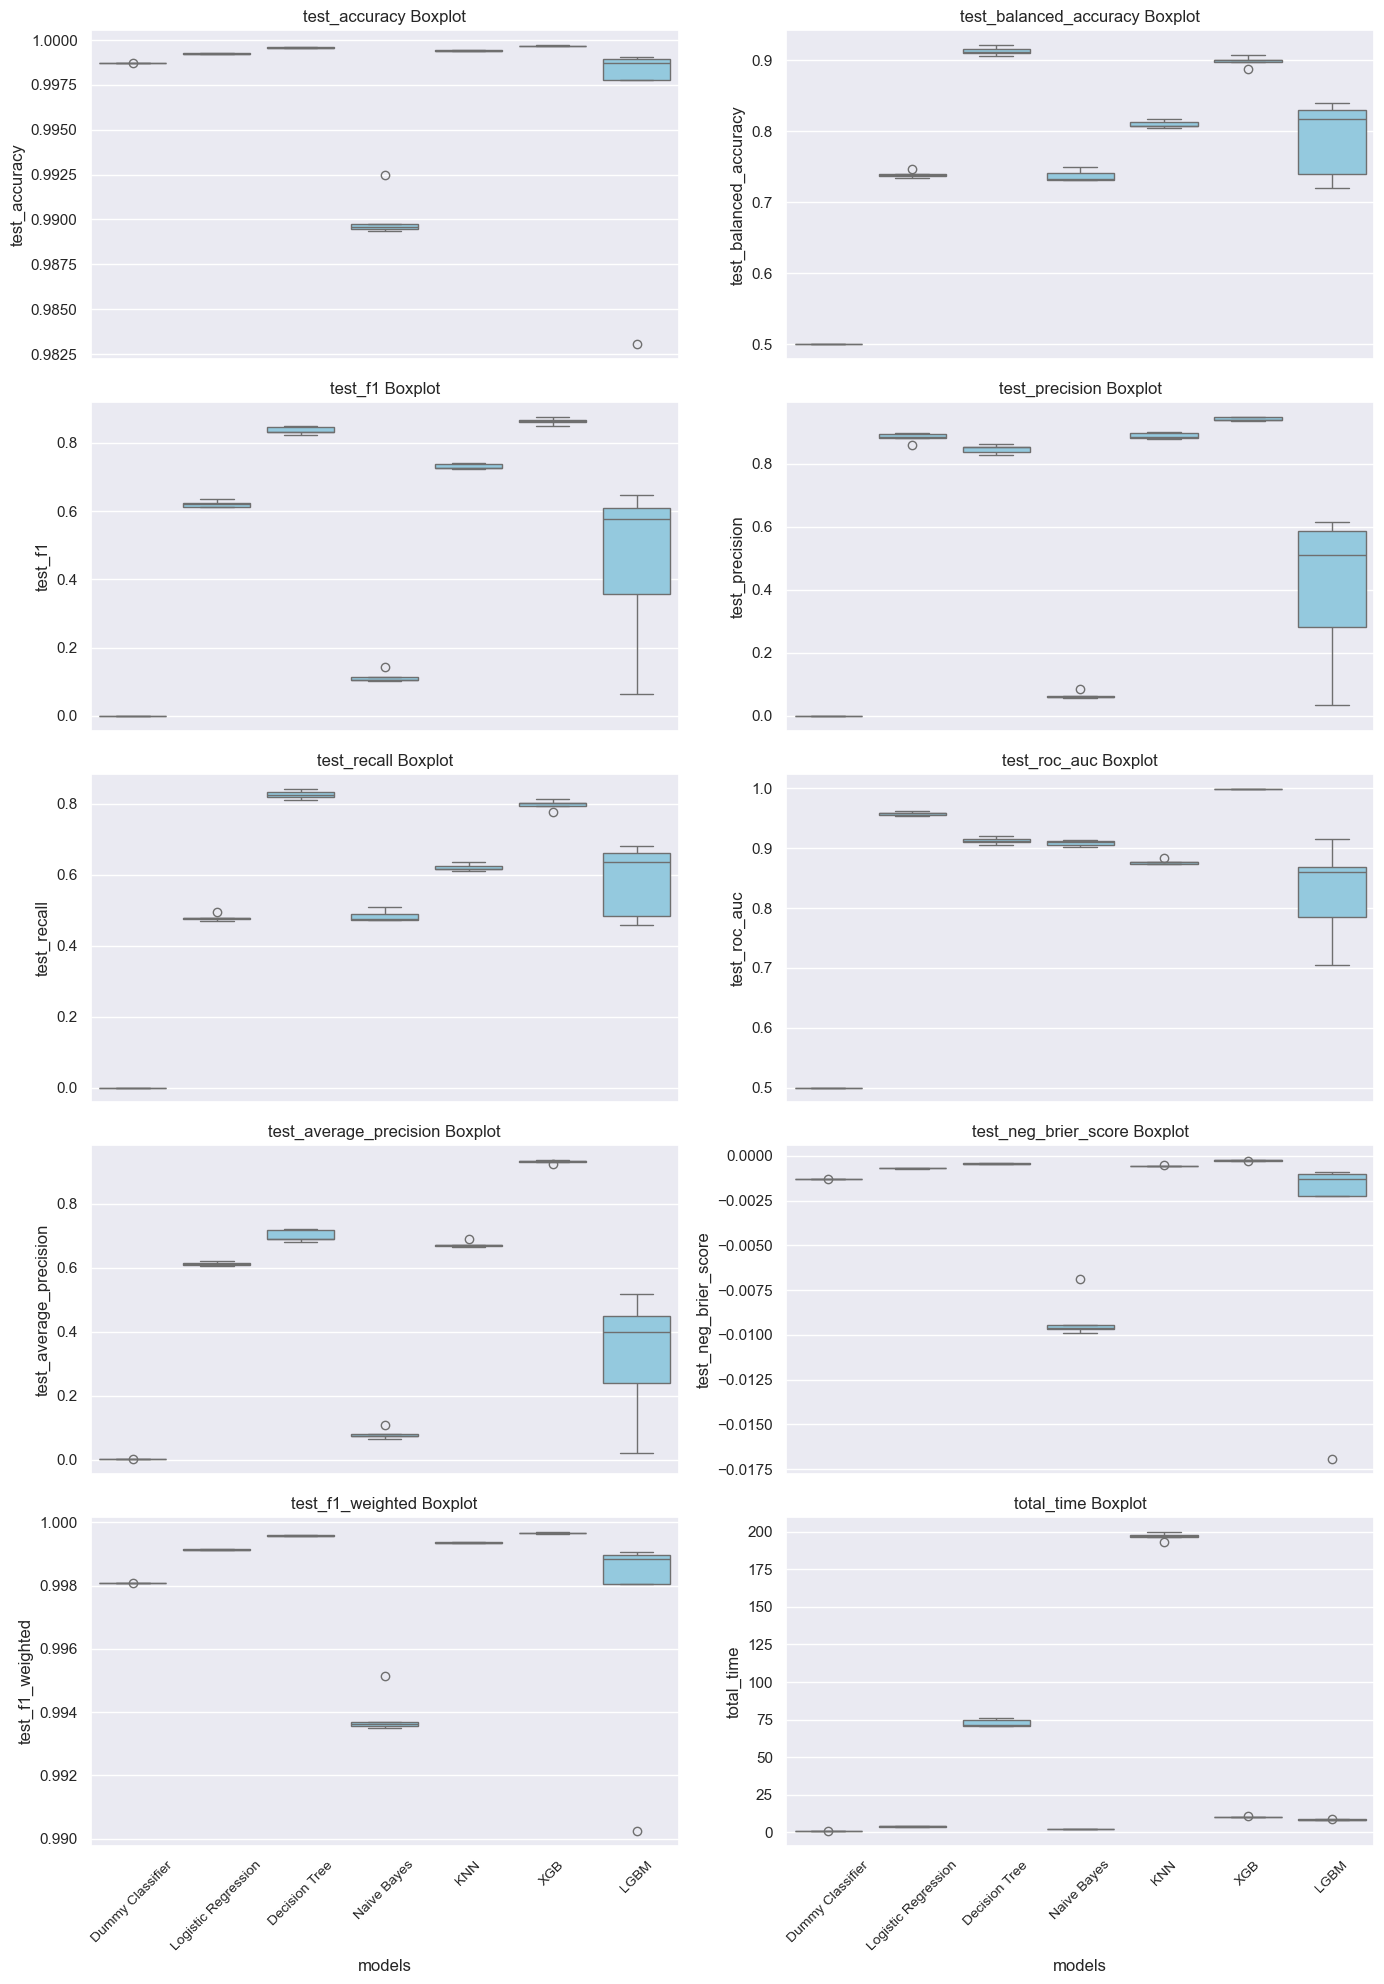

In [166]:
y_list = ['test_accuracy', 'test_balanced_accuracy', 'test_f1', 'test_precision', 
         'test_recall', 'test_roc_auc', 'test_average_precision', 'test_neg_brier_score', 
         'test_f1_weighted', 'total_time']
box_plots(df = df_results, x_val= "models", y_val_list = y_list)

With this, we observe that the XGB classifier demonstrates better performance in almost all aspects than the other classifiers, as well as an excellent time. In the next stage, the model will be fine-tuned.